# ST-GCN++ for RadHAR

Adapted to the predicted skeleton dataset in `datasets/SKradHAR`, with normalized per-joint coordinates `[x, z]` and activity labels from the class folders. The skeleton sequences are generated from `checkpoints/MARS_skdgcnn/model.pt` by `datasets/SKradHAR/skeletize.ipynb`.

We write the dimensions as such:
- T the amount of time frames per activity window (set to 30)
- C the amount of input features per joint (3 features: standardized x, standardized z, and confidence)
- V the amount of skeleton joints (set to 19)
- B the amount of batches

Across the V dimension, joints are linked by the skeleton graph, so ST-GCN++ applies graph convolutions using the Kinect adjacency. Across the T dimension, frame order represents motion, so multi-scale temporal convolutions model the activity through time.

In [5]:
from functools import lru_cache
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output
from torch.utils.data import DataLoader, Dataset

In [6]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar_ml')
SKRADHAR_ROOT = PROJECT_ROOT / 'datasets' / 'SKradHAR'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'SKradHAR_stgcnpp'

ACTIVITY_CLASS_NAMES = ('boxing', 'jack', 'jump', 'squats', 'walk')
ACTIVITY_INDEX = {name: idx for idx, name in enumerate(ACTIVITY_CLASS_NAMES)}
SKELETON_JOINT_NAMES = ('SpineBase', 'SpineMid', 'Neck', 'Head', 'ShoulderLeft', 'ElbowLeft', 'WristLeft', 'ShoulderRight', 'ElbowRight', 'WristRight', 'HipLeft', 'KneeLeft', 'AnkleLeft', 'FootLeft', 'HipRight', 'KneeRight', 'AnkleRight', 'FootRight', 'SpineShoulder')
SKELETON_JOINT_INDICES = (0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20)
CENTER_JOINT_INDEX = SKELETON_JOINT_NAMES.index('SpineShoulder')
SKELETON_EDGES = ((0, 1), (1, 18), (18, 2), (2, 3), (18, 4), (4, 5), (5, 6), (18, 7), (7, 8), (8, 9), (0, 10), (10, 11), (11, 12), (12, 13), (0, 14), (14, 15), (15, 16), (16, 17))

DEVICE = 'mps'
CONFIG = {
    'frame_count': 30,
    'stride_frame_count': 10,
    'validation_fraction': 0.1,
    'batch_size': 32,
    'num_epochs': 72,
    'base_lr': 0.1,
    'momentum': 0.9,
    'accum_iter': 1,
    'weight_decay': 5e-4,
    'dropout': 0.5,
    'base_channels': 64,
    'jitter_std': 0.01,
    'jitter_clip': 0.03,
}

# data

In [7]:
def split_skeleton_file_paths():
    "Split cached training recordings into train and validation files."
    train_files = []
    valid_files = []
    for class_name in ACTIVITY_CLASS_NAMES:
        paths = sorted((SKRADHAR_ROOT / 'Train' / class_name).glob('*.pt'))
        valid_count = max(1, int(len(paths) * CONFIG['validation_fraction']))
        valid_count = min(valid_count, len(paths) - 1)
        train_files.extend(paths[:-valid_count])
        valid_files.extend(paths[-valid_count:])
    test_files = [path for name in ACTIVITY_CLASS_NAMES for path in sorted((SKRADHAR_ROOT / 'Test' / name).glob('*.pt'))]
    return train_files, valid_files, test_files

In [8]:
def build_skeleton_windows(file_paths):
    "Create fixed-length action windows from cached skeleton recordings."
    samples = []
    for path in file_paths:
        frame_count = len(torch.load(path, weights_only=True))
        for start in range(0, frame_count - CONFIG['frame_count'] + 1, CONFIG['stride_frame_count']):
            samples.append((path, start, ACTIVITY_INDEX[path.parent.name]))
    return samples

In [9]:
@lru_cache(maxsize=None)
def skeleton_preprocessing():
    "Fit coordinate standardization on training recordings and load joint confidence."
    skeletons = []
    for path in train_files:
        skeleton = torch.load(path, weights_only=True)
        skeletons.append(skeleton - skeleton[:, CENTER_JOINT_INDEX:CENTER_JOINT_INDEX + 1])
    skeletons = torch.cat(skeletons)
    mean = skeletons.mean(dim=(0, 1))
    std = skeletons.std(dim=(0, 1)).clamp_min(1e-6)
    metadata = json.loads((SKRADHAR_ROOT / 'metadata.json').read_text())
    confidence = torch.tensor(metadata['joint_confidence_scores'], dtype=torch.float32)
    return mean, std, confidence

In [10]:
def augmentation(skeleton):
    "Add small coordinate noise to a centered training skeleton window."
    noise = torch.randn_like(skeleton) * CONFIG['jitter_std']
    return skeleton + noise.clamp(-CONFIG['jitter_clip'], CONFIG['jitter_clip'])

In [11]:
class SKRadHARDataset(Dataset):
    "RadHAR action windows represented as predicted skeletons."
    def __init__(self, samples, augment=False):
        self.samples, self.augment = samples, augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, start, label = self.samples[idx]
        skeleton = torch.load(path, weights_only=True)[start:start + CONFIG['frame_count']]
        skeleton = skeleton - skeleton[:, CENTER_JOINT_INDEX:CENTER_JOINT_INDEX + 1]
        if self.augment:
            skeleton = augmentation(skeleton)
            skeleton = skeleton - skeleton[:, CENTER_JOINT_INDEX:CENTER_JOINT_INDEX + 1]
        mean, std, confidence = skeleton_preprocessing()
        skeleton = (skeleton - mean) / std
        confidence = confidence.view(1, -1, 1).expand(skeleton.size(0), -1, 1)
        skeleton = torch.cat((skeleton, confidence), dim=2)
        return skeleton.permute(2, 0, 1), torch.tensor(label, dtype=torch.long)

In [12]:
train_files, valid_files, test_files = split_skeleton_file_paths()
train_samples = build_skeleton_windows(train_files)
valid_samples = build_skeleton_windows(valid_files)
test_samples = build_skeleton_windows(test_files)
sample_skeleton, sample_label = SKRadHARDataset(train_samples)[0]
print(f'Train/validation/test windows: {len(train_samples)}, {len(valid_samples)}, {len(test_samples)}')
print(f'Skeleton window shape: {sample_skeleton.shape} | Label: {sample_label.item()}')

Train/validation/test windows: 11939, 637, 3739
Skeleton window shape: torch.Size([3, 30, 19]) | Label: 0


# architecture

In [13]:
def build_kinect_adjacency():
    "Build identity, inward, and outward normalized Kinect graph subsets."
    joint_count = len(SKELETON_JOINT_INDICES)
    identity = torch.eye(joint_count)
    inward = torch.zeros(joint_count, joint_count)
    for source, target in SKELETON_EDGES:
        inward[target, source] = 1
    outward = inward.transpose(0, 1)
    subsets = [matrix / matrix.sum(dim=0, keepdim=True).clamp_min(1) for matrix in (identity, inward, outward)]
    return torch.stack(subsets)

In [14]:
class AdaptiveGraphConv(nn.Module):
    "ST-GCN++ spatial graph convolution with learnable adjacency residuals."
    def __init__(self, in_channels, out_channels, adjacency):
        super().__init__()
        self.adjacency = nn.Parameter(adjacency.clone())
        self.convs = nn.ModuleList([nn.Conv2d(in_channels, out_channels, 1) for _ in adjacency])
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        output = 0
        for matrix, conv in zip(self.adjacency, self.convs):
            output = output + conv(torch.einsum('nctv,vw->nctw', x, matrix))
        return self.bn(output)

In [15]:
class MultiScaleTemporalConv(nn.Module):
    "ST-GCN++ multi-branch temporal convolution module."
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        branch_channels = out_channels // 4
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv2d(in_channels, branch_channels, 1), nn.BatchNorm2d(branch_channels), nn.ReLU(), nn.Conv2d(branch_channels, branch_channels, (3, 1), stride=(stride, 1), padding=(1, 0), dilation=(1, 1)), nn.BatchNorm2d(branch_channels)),
            nn.Sequential(nn.Conv2d(in_channels, branch_channels, 1), nn.BatchNorm2d(branch_channels), nn.ReLU(), nn.Conv2d(branch_channels, branch_channels, (3, 1), stride=(stride, 1), padding=(2, 0), dilation=(2, 1)), nn.BatchNorm2d(branch_channels)),
            nn.Sequential(nn.Conv2d(in_channels, branch_channels, 1), nn.BatchNorm2d(branch_channels), nn.ReLU(), nn.MaxPool2d((3, 1), stride=(stride, 1), padding=(1, 0)), nn.BatchNorm2d(branch_channels)),
            nn.Sequential(nn.Conv2d(in_channels, branch_channels, 1, stride=(stride, 1)), nn.BatchNorm2d(branch_channels)),
        ])

    def forward(self, x):
        return torch.cat([branch(x) for branch in self.branches], dim=1)

In [16]:
class STGCNPPBlock(nn.Module):
    "One spatial graph and multi-scale temporal residual block."
    def __init__(self, in_channels, out_channels, adjacency, stride=1):
        super().__init__()
        self.graph = AdaptiveGraphConv(in_channels, out_channels, adjacency)
        self.temporal = MultiScaleTemporalConv(out_channels, out_channels, stride)
        self.residual = nn.Identity() if in_channels == out_channels and stride == 1 else nn.Sequential(nn.Conv2d(in_channels, out_channels, 1, stride=(stride, 1)), nn.BatchNorm2d(out_channels))

    def forward(self, x):
        return F.relu(self.temporal(self.graph(x)) + self.residual(x))

In [17]:
class STGCNPP(nn.Module):
    "ST-GCN++ classifier for standardized x,z skeletons with confidence."
    def __init__(self):
        super().__init__()
        channels = CONFIG['base_channels']
        adjacency = build_kinect_adjacency()
        self.data_bn = nn.BatchNorm1d(3 * len(SKELETON_JOINT_INDICES))
        self.blocks = nn.ModuleList([
            STGCNPPBlock(3, channels, adjacency), STGCNPPBlock(channels, channels, adjacency),
            STGCNPPBlock(channels, channels, adjacency), STGCNPPBlock(channels, channels, adjacency),
            STGCNPPBlock(channels, channels * 2, adjacency, stride=2), STGCNPPBlock(channels * 2, channels * 2, adjacency),
            STGCNPPBlock(channels * 2, channels * 2, adjacency), STGCNPPBlock(channels * 2, channels * 4, adjacency, stride=2),
            STGCNPPBlock(channels * 4, channels * 4, adjacency), STGCNPPBlock(channels * 4, channels * 4, adjacency),
        ])
        self.dropout = nn.Dropout(CONFIG['dropout'])
        self.classifier = nn.Linear(channels * 4, len(ACTIVITY_CLASS_NAMES))

    def forward(self, x):
        batch_size, channels, frame_count, joint_count = x.shape
        x = x.permute(0, 3, 1, 2).contiguous().view(batch_size, joint_count * channels, frame_count)
        x = self.data_bn(x).view(batch_size, joint_count, channels, frame_count).permute(0, 2, 3, 1).contiguous()
        for block in self.blocks:
            x = block(x)
        return self.classifier(self.dropout(x.mean(dim=(2, 3))))

# training

In [18]:
def create_dataloaders(batch_size):
    "Create train, validation and test dataloaders."
    train_dataset = SKRadHARDataset(train_samples, augment=True)
    valid_dataset = SKRadHARDataset(valid_samples)
    test_dataset = SKRadHARDataset(test_samples)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_dataloader, valid_dataloader, test_dataloader

In [19]:
def classification_loss(predictions, targets):
    "Cross-entropy loss."
    return F.cross_entropy(predictions, targets)

In [20]:
class Loss:
    "Categorical cross-entropy loss for activity classification."
    def __call__(self, out, targets, batch_size):
        loss_node = classification_loss(out, targets)
        loss = loss_node.detach() * batch_size
        return loss, loss_node

In [21]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, mode="train", accum_iter=1):
    "Runs one epoch, either for training, either validation."
    start, device = time.time(), torch.device(DEVICE)
    total_tokens, total_loss, tokens, n_accum = 0, 0, 0, 0
    loss_list, grad_norms = [], []
    for i, (src, targets) in enumerate(data_iter):
        src, targets = src.to(device), targets.to(device)
        ntokens = targets.size(0)
        loss, loss_node = loss_compute(model.forward(src), targets, ntokens)

        if mode == "train":
            (loss_node / accum_iter).backward()
            if i % accum_iter == 0:
                if optimizer is not None:
                    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float("inf"))
                    grad_norms.append(norm.item())
                    optimizer.step(); optimizer.zero_grad(set_to_none=True)
                n_accum += 1
        total_loss += loss; total_tokens += ntokens; tokens += ntokens
        loss_list.append((loss / ntokens).item())

        if i % 40 == 1 and mode == "train":
            lr, elapsed = optimizer.param_groups[0]["lr"], time.time() - start
            print(("Batch: %6d | Accum. Step: %3d | Loss: %6.2f " + "| Samples/sec: %7.1f | Learn. Rate: %6.1e") % (i, n_accum, loss / ntokens, tokens / elapsed, lr))
            start, tokens = time.time(), 0
    return loss_list, grad_norms

In [22]:
def plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means):
    "Plot the losses and the gradient norm over the training process."
    x_train = [e + i / s for e, s in enumerate(train_epoch_sizes) for i in range(s)]
    x_valid = [e + i / s for e, s in enumerate(valid_epoch_sizes) for i in range(s)]
    epoch_mean_valid_losses = [m for s, m in zip(valid_epoch_sizes, epoch_means) for _ in range(s)]
    plt.figure(figsize=(10, 10))
    ax1 = plt.subplot(2, 1, 1)
    w = max(1, int((len(train_losses) / num_epochs) * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=w, center=True).mean()
    plt.plot(x_train, train_losses, label="Training Loss"); plt.plot(x_train, train_loss_rolling, label="Training Loss (Avg)", color="darkblue", linewidth=1); plt.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7); plt.plot(x_valid, epoch_mean_valid_losses, label="Val Loss (Avg)", color="red", linewidth=1, linestyle="--")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Training and Validation Loss Over Epochs")
    ax1.set_xlim(0, num_epochs); ax1.set_xticks(range(num_epochs + 1))
    loss_values = pd.Series(train_losses + valid_losses + epoch_means).dropna()
    q1, q3 = loss_values.quantile(0.25), loss_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < loss_values.max(): ax1.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    y_min, y_max = ax1.get_ylim()
    best_mean_val = float("inf")
    for i, mean_val in enumerate(epoch_means):
        if mean_val <= best_mean_val and y_min <= mean_val <= y_max: ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}", color="red", ha="center", va="bottom", fontweight="medium", clip_on=True)
        best_mean_val = min(best_mean_val, mean_val)
    ax = plt.subplot(2, 1, 2)
    plt.plot(x_train, all_grad_norms, label="Gradient Norm", color="orange"); plt.xlabel("Epochs"); plt.ylabel("Norm"); plt.legend(); plt.title("Gradient Norm over Epochs")
    ax.set_xlim(0, num_epochs); ax.set_xticks(range(num_epochs + 1))
    grad_values = pd.Series(all_grad_norms).dropna()
    q1, q3 = grad_values.quantile(0.25), grad_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < grad_values.max(): ax.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="dimgray")
    plt.subplots_adjust(hspace=0.35); plt.show()

In [19]:
def train_model(num_epochs=CONFIG["num_epochs"]):
    "Train ST-GCN++ with the paper protocol."
    model = STGCNPP().to(torch.device(DEVICE))
    model_param_count = sum(p.numel() for p in model.parameters())
    train_dataloader, valid_dataloader, _ = create_dataloaders(batch_size=CONFIG["batch_size"])
    optimizer = torch.optim.SGD(model.parameters(), lr=CONFIG['base_lr'], momentum=CONFIG['momentum'], weight_decay=CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    train_losses, valid_losses, all_grad_norms = [], [], []
    train_epoch_sizes, valid_epoch_sizes, epoch_means = [], [], []
    loss_compute, checkpoint_dir = Loss(), CHECKPOINT_ROOT
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        print(f"Epoch n°{epoch} Training ====", flush=True)
        loss_list, grad_norms = run_epoch(train_dataloader, model, loss_compute,
            optimizer, mode="train", accum_iter=CONFIG["accum_iter"])
        train_losses.extend(loss_list); train_epoch_sizes.append(len(loss_list)); all_grad_norms.extend(grad_norms)
        torch.save(model.state_dict(), checkpoint_dir / f"checkpoint_{epoch:02d}.pt")
        print(f"Epoch n°{epoch} Validation ====", flush=True)
        model.eval()

        with torch.no_grad():
            loss_list, _ = run_epoch(valid_dataloader, model, loss_compute, None, mode="eval")
        valid_losses.extend(loss_list); valid_epoch_sizes.append(len(loss_list))
        mean_val = sum(loss_list) / len(loss_list)
        epoch_means.append(mean_val)
        scheduler.step()
        clear_output(wait=True)
        print("Training process starting...", flush=True)
        print(f"Epoch n°{epoch} complete | Validation loss: {mean_val:.4f}", flush=True)
        plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means)
    return model

Training process starting...
Epoch n°99 complete | Validation loss: 0.3519


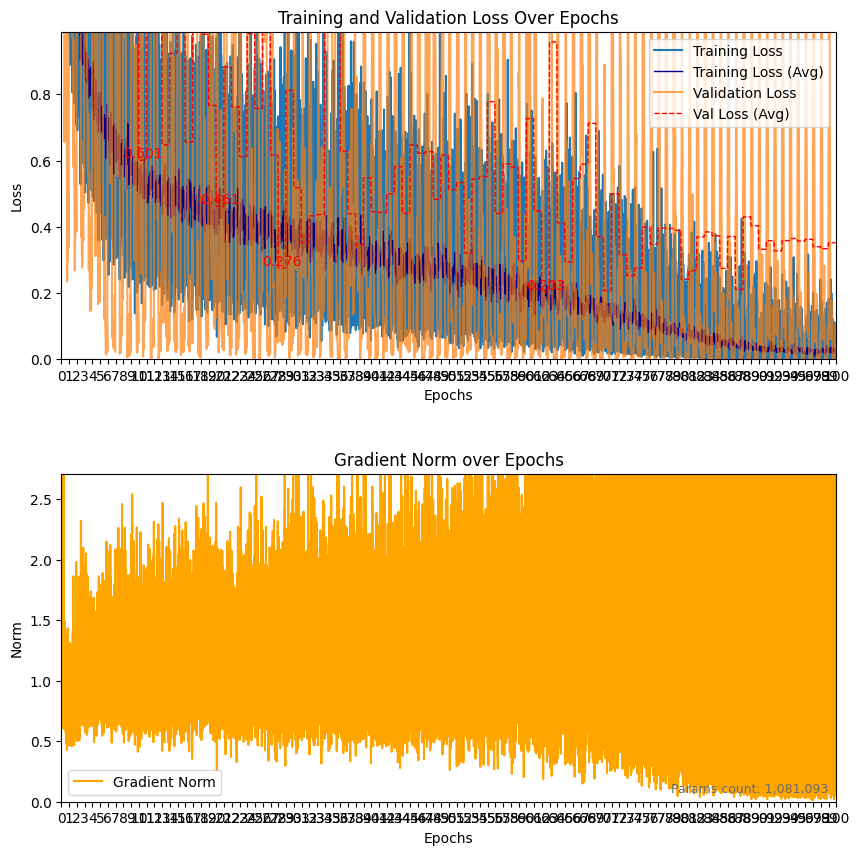

In [ ]:
if __name__ == "__main__":
    train_model(150)

# inference

In [23]:
def compute_macro_f1(predictions, labels):
    scores = []
    for class_idx in range(len(ACTIVITY_CLASS_NAMES)):
        true_positive = ((predictions == class_idx) & (labels == class_idx)).sum().item()
        false_positive = ((predictions == class_idx) & (labels != class_idx)).sum().item()
        false_negative = ((predictions != class_idx) & (labels == class_idx)).sum().item()
        denominator = 2 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0 else 2 * true_positive / denominator)
    return torch.tensor(scores, dtype=torch.float32)

In [24]:
def evaluate_validation_checkpoint(checkpoint_path):
    "Score a checkpoint on validation only."
    device, model = torch.device(DEVICE), STGCNPP().to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    model.eval()
    _, valid_dataloader, _ = create_dataloaders(CONFIG["batch_size"])
    all_predictions, all_labels = [], []
    
    with torch.no_grad():
        for batch, labels in valid_dataloader:
            all_predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            all_labels.append(labels.cpu())
    predictions, labels = torch.cat(all_predictions), torch.cat(all_labels)
    per_class_f1 = compute_macro_f1(predictions, labels)
    return per_class_f1.mean().item(), {name: float(score) for name, score in zip(ACTIVITY_CLASS_NAMES, per_class_f1)}, (predictions == labels).float().mean().item()

In [25]:
def evaluate_test_checkpoint(checkpoint_path):
    "Score one selected checkpoint on the held-out RadHAR test recordings."
    device, model = torch.device(DEVICE), STGCNPP().to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    model.eval()
    _, _, test_dataloader = create_dataloaders(CONFIG['batch_size'])
    all_predictions, all_labels = [], []
    with torch.no_grad():
        for batch, labels in test_dataloader:
            all_predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            all_labels.append(labels.cpu())
    predictions, labels = torch.cat(all_predictions), torch.cat(all_labels)
    per_class_f1 = compute_macro_f1(predictions, labels)
    return per_class_f1.mean().item(), (predictions == labels).float().mean().item(), per_class_f1

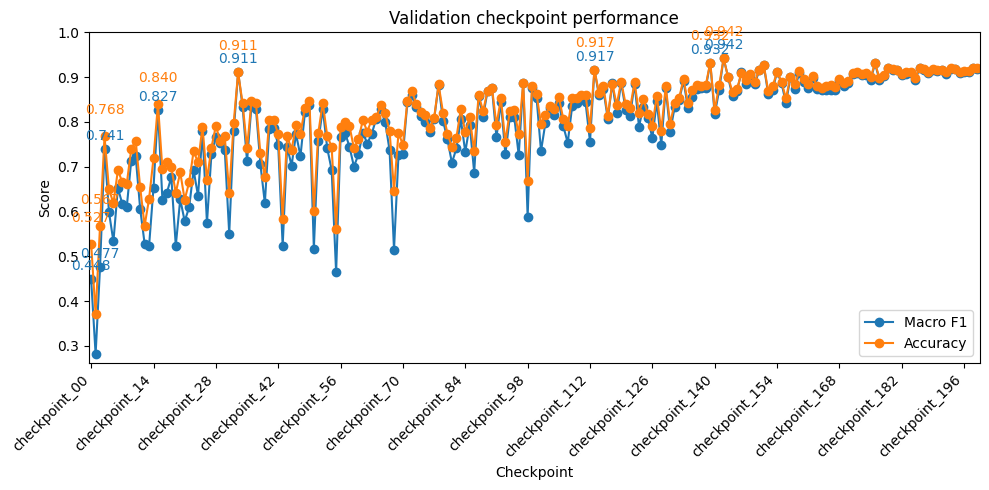

In [26]:
checkpoint_paths = sorted(CHECKPOINT_ROOT.glob('checkpoint_*.pt'), key=lambda path: int(path.stem.split('_')[-1]))
metrics = [evaluate_validation_checkpoint(path) for path in checkpoint_paths]
checkpoint_numbers = [int(path.stem.split("_")[-1]) for path in checkpoint_paths]
checkpoint_labels = [path.stem for path in checkpoint_paths]
macro_f1_scores, accuracy_scores = ([metric[i] for metric in metrics] for i in (0, 2))

fig, ax = plt.subplots(figsize=(10, 5))
lines = [ax.plot(checkpoint_numbers, scores, marker="o", label=label)[0] for scores, label in ((macro_f1_scores, "Macro F1"), (accuracy_scores, "Accuracy"))]
for scores, line, offset in zip((macro_f1_scores, accuracy_scores), lines, (0.02, 0.05)):
    best = -1
    for checkpoint, score in zip(checkpoint_numbers, scores):
        if score > best:
            ax.text(checkpoint, score + offset, f"{score:.3f}", ha="center", color=line.get_color())
            best = score

tick_step = 1 if len(checkpoint_labels) <= 20 else max(2, (len(checkpoint_labels) + 14) // 15)
tick_indices = list(range(0, len(checkpoint_labels), tick_step))
ax.set_xticks([checkpoint_numbers[i] for i in tick_indices], [checkpoint_labels[i] for i in tick_indices], rotation=45, ha="right")
ax.set_xlim(checkpoint_numbers[0] - 0.5, checkpoint_numbers[-1] + 0.5); ax.set_ylim(min(macro_f1_scores + accuracy_scores) - 0.02, 1)
ax.set_xlabel("Checkpoint"); ax.set_ylabel("Score"); ax.set_title("Validation checkpoint performance")
ax.legend(); fig.tight_layout(); plt.show()

In [27]:
best_idx = max(range(len(accuracy_scores)), key=lambda idx: (round(accuracy_scores[idx], 4), idx))
best_checkpoint_path = checkpoint_paths[best_idx]
test_macro_f1, test_accuracy, per_class_f1 = evaluate_test_checkpoint(best_checkpoint_path)
print(f'Best validation checkpoint: {best_checkpoint_path.name}')
print(f'Validation accuracy: {accuracy_scores[best_idx]:.4f}')
print(f'Test macro F1: {test_macro_f1:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
print(dict(zip(ACTIVITY_CLASS_NAMES, per_class_f1.tolist())))

Best validation checkpoint: checkpoint_142.pt
Validation accuracy: 0.9419
Test macro F1: 0.8724
Test accuracy: 0.8706
{'boxing': 0.8640569448471069, 'jack': 0.9213793277740479, 'jump': 0.7986440658569336, 'squats': 0.9483240246772766, 'walk': 0.8298368453979492}
